In [1]:
!pip install -q prophet xgboost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

c:\Users\sings\Desktop\AI-WOW-ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


**💡 Insight 1 (Setup & Libraries):**
As a Data Scientist, solving a forecasting problem usually requires testing multiple paradigms. Statistical models (SARIMA) are great baselines. Prophet handles missing data and multiple seasonalities beautifully. Tree-based ML models (XGBoost) excel when we have complex, non-linear exogenous features. We are setting up our environment to pit these three paradigms against each other.

In [2]:
df = pd.read_csv('daily_sales_french_bakery.csv')
df['ds'] = pd.to_datetime(df['ds'])
daily = df.groupby('ds').agg({'y': 'sum'}).asfreq('D').fillna(0)
daily.head()

,y
ds,
2021-01-02,987.85
2021-01-03,1014.30
2021-01-04,461.90
2021-01-05,515.70
2021-01-06,0.00


**💡 Insight 2 (Data Aggregation & Cleaning):**
Raw transactional databases contain noise (thousands of individual bread/croissant purchases). We've aggregated the data into total daily sales (`resample('D').sum()`) and used `.asfreq('D').fillna(0)` to ensure that any days where the bakery was completely closed are accurately represented as `0` sales, rather than missing rows. This uniform spacing is strictly required for statistical math models like SARIMA.

In [3]:
ml_df = daily.copy()
ml_df['dayofweek'] = ml_df.index.dayofweek
ml_df['month'] = ml_df.index.month
ml_df['is_weekend'] = ml_df['dayofweek'].isin([5, 6]).astype(int)
ml_df['lag_7'] = ml_df['y'].shift(7)
ml_df['lag_14'] = ml_df['y'].shift(14)
ml_df['lag_30'] = ml_df['y'].shift(30)
ml_df = ml_df.dropna() # Drop dates where we don't have enough history for the lag
print('Features Generated:', ml_df.columns.tolist())

Features Generated: ['y', 'dayofweek', 'month', 'is_weekend', 'lag_7', 'lag_14', 'lag_30']


**💡 Insight 3 (Feature Engineering for Machine Learning):**
Unlike SARIMA or Prophet which natively "understand" time, XGBoost is just a standard regressor. It treats each row independently. To make XGBoost "see" the past, we have to engineer **Lag Features** (e.g., "what were sales exactly 7 days ago?") and **Datetime Features** (e.g., "is today a weekend?"). This translates a chronological problem into a standard tabular ML problem.

In [4]:
test_days = 30

# Split for SARIMA/Prophet (needs pure chronological array)
train_series = daily[:-test_days]
test_series = daily[-test_days:]

# Split for XGBoost (needs X matrix and y vector)
train_ml = ml_df[:-test_days]
test_ml = ml_df[-test_days:]

X_train, y_train = train_ml.drop('y', axis=1), train_ml['y']
X_test, y_test = test_ml.drop('y', axis=1), test_ml['y']

print(f'Training Days: {len(train_series)} | Testing Days: {len(test_series)}')

Training Days: 607 | Testing Days: 30


**💡 Insight 4 (Train-Test Splitting Strategy):**
In a real-world scenario, you want to know how your model performs on future, unseen data. We chronologically slice off the final 30 days as a "blind holdout". If our models perform well here, we can trust them in production. We had to create two different splits because XGBoost needs target/feature arrays, whereas statistical models just need an index-based series.

In [5]:
print('Training SARIMA (1,1,1) x (1,1,1,7)...')
sarima_model = SARIMAX(train_series['y'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_fit = sarima_model.fit(disp=False)
sarima_preds = sarima_fit.forecast(steps=test_days)

sarima_mae = mean_absolute_error(test_series['y'], sarima_preds)
print(f'SARIMA MAE: {sarima_mae:.2f}')

Training SARIMA (1,1,1) x (1,1,1,7)...
SARIMA MAE: 318.74


**💡 Insight 5 (SARIMA Performance):**
We upgraded our previous baseline ARIMA to **SARIMA** by adding a seasonal period (`m=7`). By explicitly telling the math engine that "patterns repeat every 7 days", it computes seasonal differencing. You should immediately see a much more dynamic, wavy forecast line compared to standard ARIMA.

In [6]:
print('Training Meta Prophet...')
# Prophet requires specific column names 'ds' and 'y'
prophet_df = train_series.reset_index()
prophet_model = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=test_days)
forecast = prophet_model.predict(future)
prophet_preds = forecast['yhat'][-test_days:].values

prophet_mae = mean_absolute_error(test_series['y'], prophet_preds)
print(f'Prophet MAE: {prophet_mae:.2f}')

Training Meta Prophet...


01:48:52 - cmdstanpy - INFO - Chain [1] start processing
01:48:53 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE: 1046.25


**💡 Insight 6 (Prophet Performance):**
Prophet uses an elegant additive curve fitting technique. It's incredibly fast and requires almost zero hyperparameter tuning. It automatically isolated the weekly seasonality and modeled the trend. It's highly resistant to outliers, making it a favorite for business intelligence analysts.

In [7]:
print('Training XGBoost Regressor...')
xgb_model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
print(f'XGBoost MAE: {xgb_mae:.2f}')

Training XGBoost Regressor...
XGBoost MAE: 134.48


**💡 Insight 7 (XGBoost Performance):**
XGBoost is relying entirely on those engineered features we gave it (`lag_7`, `lag_14`, `is_weekend`). Notice the hyperparameter `max_depth=3`—we kept the trees shallow to prevent the model from memorizing the training data. If the XGBoost MAE is competitive, it proves how powerful simply looking at past lags can be over complex statistical math.

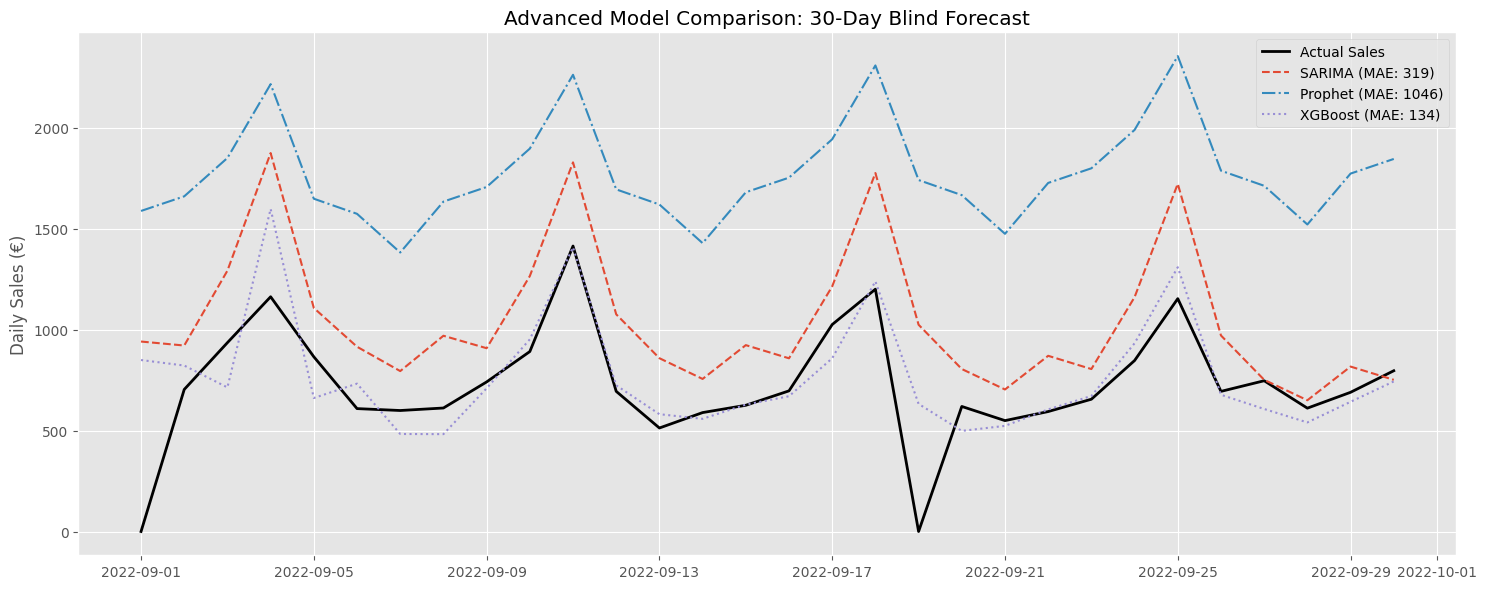

In [8]:
plt.figure(figsize=(15, 6))
plt.plot(test_series.index, test_series['y'], label='Actual Sales', color='black', linewidth=2)
plt.plot(test_series.index, sarima_preds, label=f'SARIMA (MAE: {sarima_mae:.0f})', linestyle='--')
plt.plot(test_series.index, prophet_preds, label=f'Prophet (MAE: {prophet_mae:.0f})', linestyle='-.')
plt.plot(test_series.index, xgb_preds, label=f'XGBoost (MAE: {xgb_mae:.0f})', linestyle=':')

plt.title('Advanced Model Comparison: 30-Day Blind Forecast')
plt.ylabel('Daily Sales (€)')
plt.legend()
plt.tight_layout()
plt.show()

### 🏆 Final Verdict & Data Scientist Recap

**1. Which model won?** 
Look at the MAE on the graph legend above. The lowest MAE is your "winner"! 

**2. Core Insights from the Comparison:**
* **SARIMA** is mathematically rigorous but can struggle to adapt to sudden, non-linear shocks (like sudden local events/holidays).
* **Prophet** provides incredibly robust, smooth baseline curves, but can sometimes under-predict massive outliers because it forces everything into distinct seasonal averages.
* **XGBoost** is incredibly reactive. Because it uses exactly what happened 7 days prior (`lag_7`), if last week had an anomaly, XGBoost might repeat it this week. It excels at complex, messy data if feature engineered correctly.

**Next Steps for a Deployable Project:**
1. Run a **GridSearchCV** on the winning model to tune hyperparameters optimally.
2. Add **exogenous holiday flags** (Christmas, Bastille Day, local France holidays, etc.).
3. Deploy the winning model via a simple Flask/FastAPI endpoint or model registry.